### Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Show all columns in output
pd.set_option('display.max_columns', None)

### Load dataset

In [3]:
restaurants = pd.read_csv(r'E:\Data Science Projects\02 Restaurant Consulting Service\restaurant_consulting\data\restaurants.csv')
customers   = pd.read_csv(r'E:\Data Science Projects\02 Restaurant Consulting Service\restaurant_consulting\data\customers.csv')
orders      = pd.read_csv(r'E:\Data Science Projects\02 Restaurant Consulting Service\restaurant_consulting\data\orders.csv')
reviews     = pd.read_csv(r'E:\Data Science Projects\02 Restaurant Consulting Service\restaurant_consulting\data\reviews.csv')

In [4]:
print(f'restaurants : {restaurants.shape}')
print(f'customers   : {customers.shape}')
print(f'orders      : {orders.shape}')
print(f'reviews     : {reviews.shape}')

restaurants : (3000, 14)
customers   : (10000, 10)
orders      : (50000, 12)
reviews     : (30846, 10)


### Explore Restaurants Table

In [6]:
restaurants.head()

,restaurant_id,restaurant_name,owner_name,city,area,latitude,longitude,cuisine_type,restaurant_type,avg_price_for_two,has_online_ordering,has_table_booking,opening_year,is_active
0,R1001,Royal Kitchen,Neha Desai,Hyderabad,Banjara Hills,17.484118,78.485340,Mughlai,Cloud Kitchen,212,False,False,2011,True
1,R1002,Om Lounge,Nikhil Khanna,Delhi,Pitampura,28.675331,77.175856,Mughlai,Fine Dining,1650,True,True,2023,True
2,R1003,Dum Corner,Isha Gupta,Mumbai,Versova,19.025643,72.848791,North Indian,QSR,260,True,False,2010,True
3,R1004,Golden Hub,Ananya Deshpande,Bangalore,Hebbal,12.898072,77.517389,Desserts & Beverages,Cafe,1200,True,False,2022,True
4,R1005,Dhaba Palace,Preeti Malhotra,Delhi,South Extension,28.552377,77.130093,Chinese,Cafe,550,False,False,2020,True


In [7]:
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   restaurant_id        3000 non-null   object 
 1   restaurant_name      3000 non-null   object 
 2   owner_name           3000 non-null   object 
 3   city                 3000 non-null   object 
 4   area                 3000 non-null   object 
 5   latitude             3000 non-null   float64
 6   longitude            3000 non-null   float64
 7   cuisine_type         3000 non-null   object 
 8   restaurant_type      3000 non-null   object 
 9   avg_price_for_two    3000 non-null   int64  
 10  has_online_ordering  3000 non-null   bool   
 11  has_table_booking    3000 non-null   bool   
 12  opening_year         3000 non-null   int64  
 13  is_active            3000 non-null   bool   
dtypes: bool(3), float64(2), int64(2), object(7)
memory usage: 266.7+ KB


In [8]:
restaurants.describe()

,latitude,longitude,avg_price_for_two,opening_year
count,3000.000000,3000.000000,3000.000000,3000.00000
mean,19.578132,77.169952,764.876000,2016.57700
std,5.550943,3.736775,598.892309,4.06369
min,12.851178,72.780860,120.000000,2010.00000
25%,13.152898,73.880569,275.000000,2013.00000
50%,18.597887,77.299308,545.000000,2017.00000
75%,22.573730,78.401782,1085.000000,2020.00000
max,28.749955,88.448916,2600.000000,2023.00000


In [10]:
print('Missing values in restaurants:')
print(restaurants.isnull().sum())

print('\nDuplicate rows:', restaurants.duplicated().sum())

Missing values in restaurants:
restaurant_id          0
restaurant_name        0
owner_name             0
city                   0
area                   0
latitude               0
longitude              0
cuisine_type           0
restaurant_type        0
avg_price_for_two      0
has_online_ordering    0
has_table_booking      0
opening_year           0
is_active              0
dtype: int64

Duplicate rows: 0


In [11]:
print('Unique values in key columns:')
print('Cities       :', restaurants['city'].unique())
print('Cuisines     :', restaurants['cuisine_type'].nunique(), 'types')
print('Rest. Types  :', restaurants['restaurant_type'].unique())

Unique values in key columns:
Cities       : ['Hyderabad' 'Delhi' 'Mumbai' 'Bangalore' 'Pune' 'Chennai' 'Kolkata']
Cuisines     : 15 types
Rest. Types  : ['Cloud Kitchen' 'Fine Dining' 'QSR' 'Cafe' 'Casual Dining' 'Dine-in']


### Explore Customers Table

In [13]:
customers.head()

,customer_id,customer_name,age,gender,city,area,preferred_cuisine,avg_monthly_orders,is_premium_user,joined_year
0,C10001,Amit Bhat,33,Female,Delhi,South Extension,Chinese,6,False,2023
1,C10002,Pallavi Kapoor,28,Male,Delhi,Vasant Kunj,Street Food,4,False,2017
2,C10003,Alok Jain,28,Male,Chennai,Vadapalani,Chinese,1,False,2022
3,C10004,Alok Pandey,28,Male,Delhi,Lajpat Nagar,North Indian,10,False,2021
4,C10005,Mohit Tiwari,42,Female,Mumbai,Kandivali,South Indian,1,True,2017


In [14]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         10000 non-null  object
 1   customer_name       10000 non-null  object
 2   age                 10000 non-null  int64 
 3   gender              10000 non-null  object
 4   city                10000 non-null  object
 5   area                10000 non-null  object
 6   preferred_cuisine   10000 non-null  object
 7   avg_monthly_orders  10000 non-null  int64 
 8   is_premium_user     10000 non-null  bool  
 9   joined_year         10000 non-null  int64 
dtypes: bool(1), int64(3), object(6)
memory usage: 713.0+ KB


In [15]:
print('Missing values in customers:')
print(customers.isnull().sum())

print('\nAge range:', customers['age'].min(), 'to', customers['age'].max())
print('Premium users:', customers['is_premium_user'].sum(), '/', len(customers))

Missing values in customers:
customer_id           0
customer_name         0
age                   0
gender                0
city                  0
area                  0
preferred_cuisine     0
avg_monthly_orders    0
is_premium_user       0
joined_year           0
dtype: int64

Age range: 18 to 55
Premium users: 2262 / 10000


### Explore Orders Table

In [16]:
orders.head()

,order_id,customer_id,restaurant_id,order_date,order_time_slot,items_ordered,total_amount,discount_applied,payment_mode,delivery_time_mins,order_status,is_reorder
0,ORD100001,C15710,R1213,2023-04-17,Late Night,"Pani Puri, Kachori",666.19,0.00,UPI,32,Delivered,False
1,ORD100002,C17906,R1400,2022-06-28,Lunch,"Fried Rice, Hakka Noodles, Hot & Sour Soup",480.07,143.12,Wallet,25,Delivered,False
2,ORD100003,C14624,R1524,2022-10-05,Lunch,Burger,119.90,0.00,Net Banking,44,Cancelled,False
3,ORD100004,C19306,R3113,2023-05-27,Late Night,"Pani Puri, Dabeli, Pav Bhaji",2159.62,107.24,UPI,17,Delivered,False
4,ORD100005,C19947,R1107,2023-03-15,Snacks,"Paneer Tikka, Rajma Chawal, Dal Makhani",1288.92,0.00,Card,34,Delivered,False


In [17]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            50000 non-null  object 
 1   customer_id         50000 non-null  object 
 2   restaurant_id       50000 non-null  object 
 3   order_date          50000 non-null  object 
 4   order_time_slot     50000 non-null  object 
 5   items_ordered       50000 non-null  object 
 6   total_amount        50000 non-null  float64
 7   discount_applied    50000 non-null  float64
 8   payment_mode        50000 non-null  object 
 9   delivery_time_mins  50000 non-null  int64  
 10  order_status        50000 non-null  object 
 11  is_reorder          50000 non-null  bool   
dtypes: bool(1), float64(2), int64(1), object(8)
memory usage: 4.2+ MB


In [18]:
print('Order status distribution:')
print(orders['order_status'].value_counts())

print('\nPayment mode distribution:')
print(orders['payment_mode'].value_counts())

print('\nTotal amount - min:', orders['total_amount'].min(), '| max:', orders['total_amount'].max())

Order status distribution:
order_status
Delivered    41128
Cancelled     5377
Rejected      3495
Name: count, dtype: int64

Payment mode distribution:
payment_mode
UPI            22379
Card           12578
Wallet          7426
COD             5077
Net Banking     2540
Name: count, dtype: int64

Total amount - min: 38.22 | max: 3115.6


### Explore Reviews Table

In [19]:
reviews.head()

,review_id,order_id,customer_id,restaurant_id,food_rating,delivery_rating,overall_rating,review_text,review_date,helpful_votes
0,REV10001,ORD130133,C12901,R3592,3.4,4.6,4.1,"Very fresh ingredients, absolutely delicious.",2023-12-20,4
1,REV10002,ORD130982,C11811,R2382,4.6,4.5,4.7,"Value for money, loved it.",2023-05-04,19
2,REV10003,ORD112091,C17882,R3960,3.3,3.9,3.8,Delivery was late but food was good.,2022-11-02,10
3,REV10004,ORD121846,C10070,R3270,3.2,4.1,3.5,"Could be better, but not bad.",2022-04-04,10
4,REV10005,ORD118675,C10494,R2897,4.5,4.0,4.2,"Very fresh ingredients, absolutely delicious.",2021-12-01,2


In [20]:
print('Average Ratings:')
print('Food rating     :', round(reviews['food_rating'].mean(), 2))
print('Delivery rating :', round(reviews['delivery_rating'].mean(), 2))
print('Overall rating  :', round(reviews['overall_rating'].mean(), 2))

Average Ratings:
Food rating     : 4.11
Delivery rating : 3.82
Overall rating  : 4.0


### Check Relationships Between Tables

In [21]:
# Check if all order customer_ids exist in customers table
valid_customers = orders['customer_id'].isin(customers['customer_id']).sum()
print(f'Orders with valid customer_id : {valid_customers} / {len(orders)}')

# Check if all order restaurant_ids exist in restaurants table
valid_restaurants = orders['restaurant_id'].isin(restaurants['restaurant_id']).sum()
print(f'Orders with valid restaurant_id: {valid_restaurants} / {len(orders)}')

# Check reviews → orders
valid_orders = reviews['order_id'].isin(orders['order_id']).sum()
print(f'Reviews with valid order_id    : {valid_orders} / {len(reviews)}')

Orders with valid customer_id : 50000 / 50000
Orders with valid restaurant_id: 50000 / 50000
Reviews with valid order_id    : 30846 / 30846


### Summary

In [ ]:
# No missing values found
# No duplicate rows
# All foreign key relationships are valid

### Exploratory Data Analysis

### Plot 1 — Number of Restaurants per City

C:\Users\Care\AppData\Local\Temp\ipykernel_2000\2994661725.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.index, y=city_counts.values, palette='Set2')


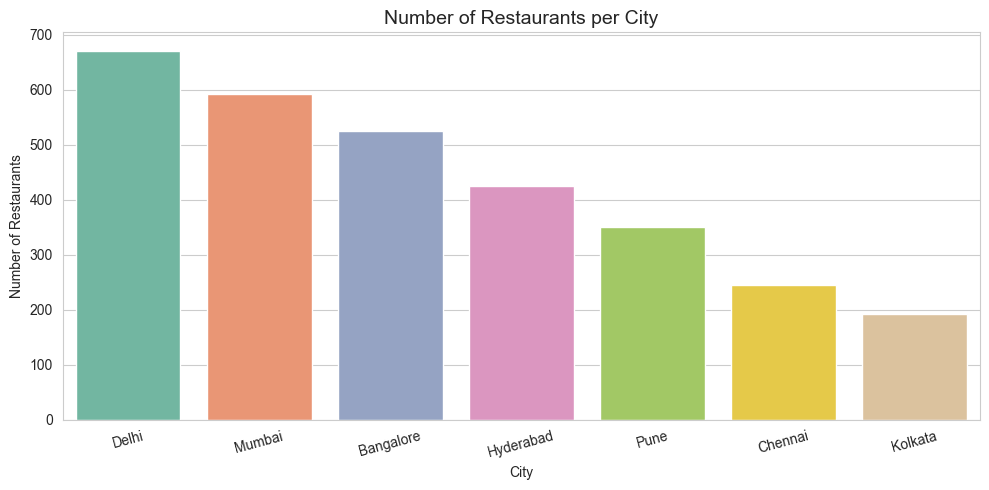

In [24]:
city_counts = restaurants['city'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=city_counts.index, y=city_counts.values, palette='Set2')
plt.title('Number of Restaurants per City', fontsize=14)
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Plot 2 — Top 10 Most Common Cuisines

C:\Users\Care\AppData\Local\Temp\ipykernel_2000\2752484515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index, palette='coolwarm')


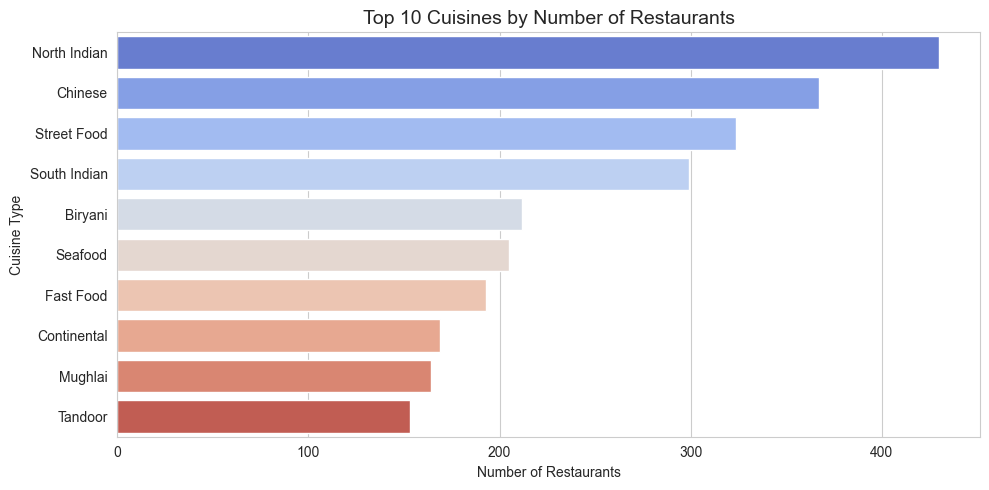

In [27]:
cuisine_counts = restaurants['cuisine_type'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index, palette='coolwarm')
plt.title('Top 10 Cuisines by Number of Restaurants', fontsize=14)
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine Type')
plt.tight_layout()
plt.show()

### Plot 3 — Average Price for Two by City

C:\Users\Care\AppData\Local\Temp\ipykernel_2000\4220244924.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, palette='Blues_d')


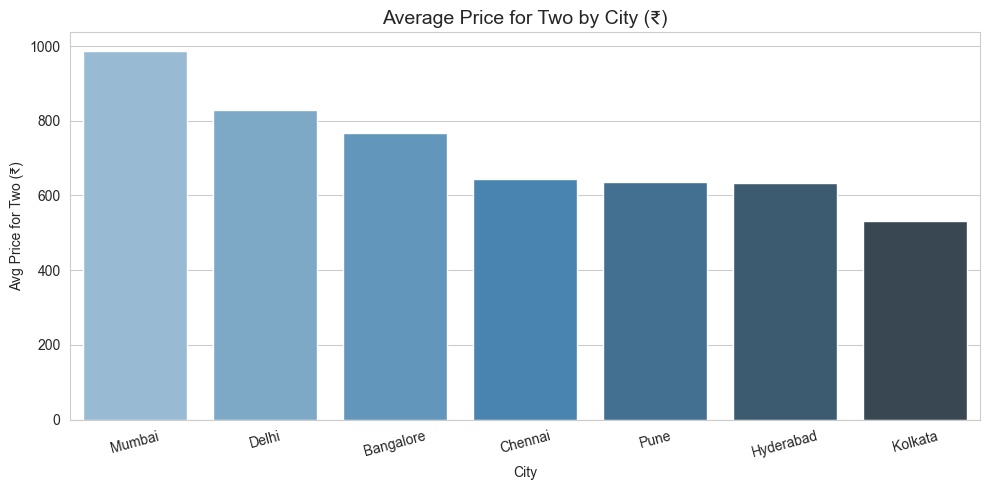

In [28]:
avg_price = restaurants.groupby('city')['avg_price_for_two'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_price.index, y=avg_price.values, palette='Blues_d')
plt.title('Average Price for Two by City (₹)', fontsize=14)
plt.xlabel('City')
plt.ylabel('Avg Price for Two (₹)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Plot 4 — Restaurant Type Distribution

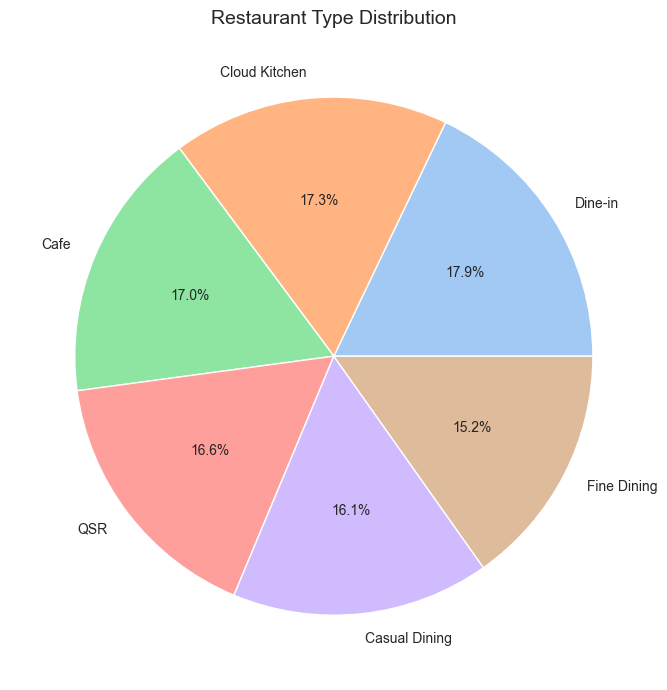

In [29]:
type_counts = restaurants['restaurant_type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'))
plt.title('Restaurant Type Distribution', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 5 — Order Status Distribution

C:\Users\Care\AppData\Local\Temp\ipykernel_2000\1010257273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette='Set3')


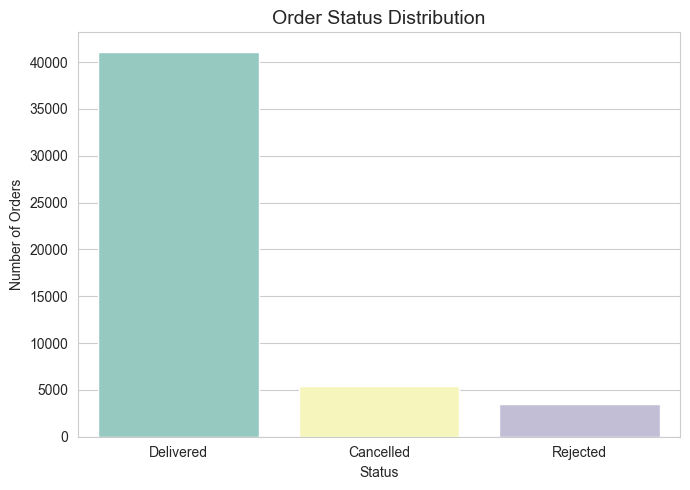

In [30]:
status_counts = orders['order_status'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=status_counts.index, y=status_counts.values, palette='Set3')
plt.title('Order Status Distribution', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### Plot 6 — Orders by Time Slot

C:\Users\Care\AppData\Local\Temp\ipykernel_2000\2258269934.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=slot_counts.index, y=slot_counts.values, palette='YlOrRd')


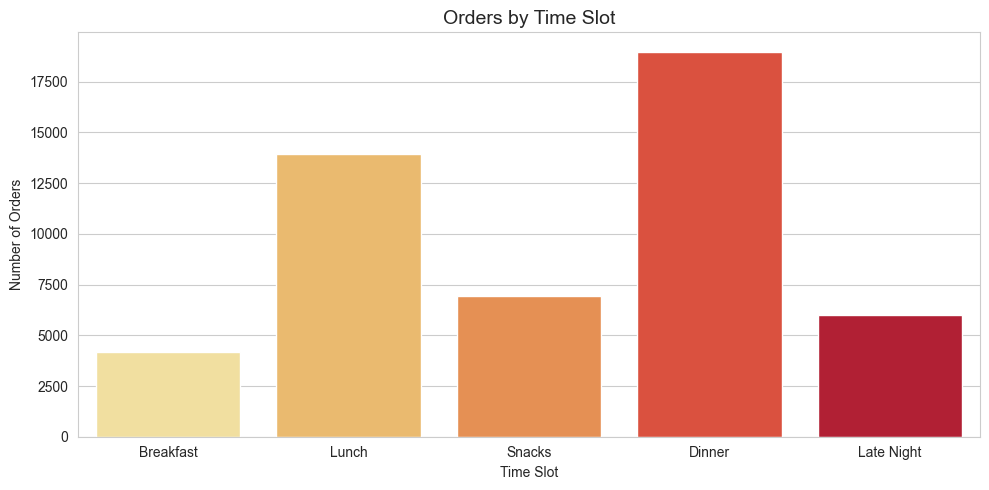

In [31]:
slot_order = ['Breakfast', 'Lunch', 'Snacks', 'Dinner', 'Late Night']
slot_counts = orders['order_time_slot'].value_counts().reindex(slot_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=slot_counts.index, y=slot_counts.values, palette='YlOrRd')
plt.title('Orders by Time Slot', fontsize=14)
plt.xlabel('Time Slot')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### Plot 7 — Monthly Order Trend (2021–2023)

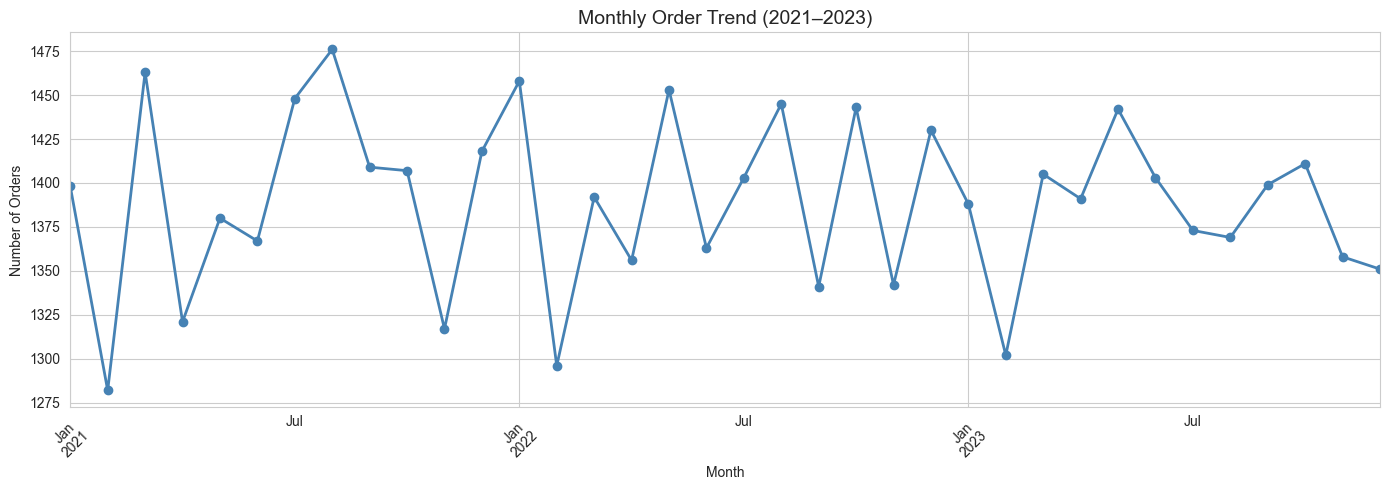

In [32]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['year_month'] = orders['order_date'].dt.to_period('M')

monthly_orders = orders.groupby('year_month').size()

plt.figure(figsize=(14, 5))
monthly_orders.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Order Trend (2021–2023)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plot 8 — Overall Rating Distribution

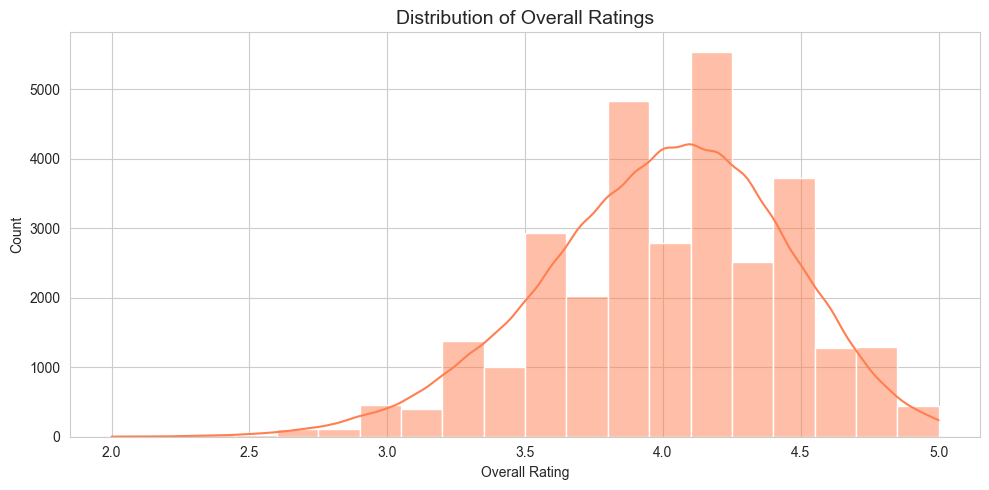

In [33]:
plt.figure(figsize=(10, 5))
sns.histplot(reviews['overall_rating'], bins=20, kde=True, color='coral')
plt.title('Distribution of Overall Ratings', fontsize=14)
plt.xlabel('Overall Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Plot 9 — Average Rating by Cuisine Type

C:\Users\Care\AppData\Local\Temp\ipykernel_2000\2079533318.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_cuisine.index, y=avg_rating_cuisine.values, palette='viridis')


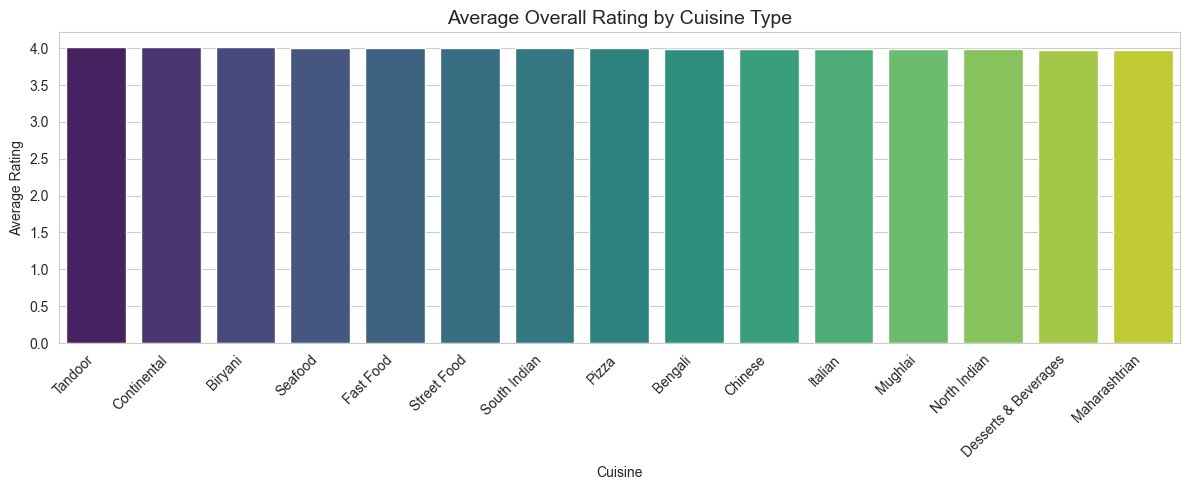

In [34]:
# Merge reviews with restaurants to get cuisine info
reviews_with_cuisine = reviews.merge(
    restaurants[['restaurant_id', 'cuisine_type']], on='restaurant_id'
)

avg_rating_cuisine = reviews_with_cuisine.groupby('cuisine_type')['overall_rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=avg_rating_cuisine.index, y=avg_rating_cuisine.values, palette='viridis')
plt.title('Average Overall Rating by Cuisine Type', fontsize=14)
plt.xlabel('Cuisine')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Plot 10 — Correlation Heatmap (Numerical Columns)

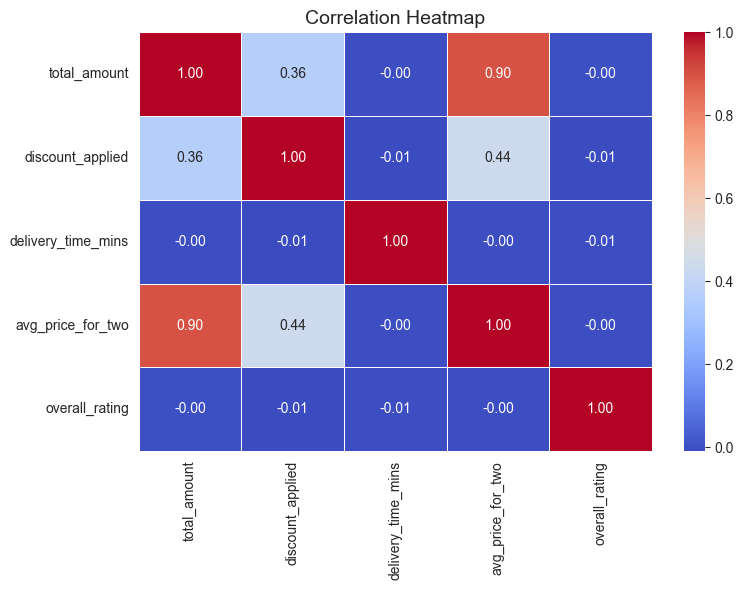

In [35]:
# Merge orders with restaurants for numerical analysis
merged = orders.merge(restaurants[['restaurant_id','avg_price_for_two']], on='restaurant_id')
merged = merged.merge(reviews[['order_id','overall_rating']], on='order_id', how='left')

num_cols = ['total_amount', 'discount_applied', 'delivery_time_mins', 'avg_price_for_two', 'overall_rating']
corr_matrix = merged[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 11 — Top 10 Areas by Number of Orders

C:\Users\Care\AppData\Local\Temp\ipykernel_2000\126080954.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_areas.values, y=top_areas.index, palette='magma')


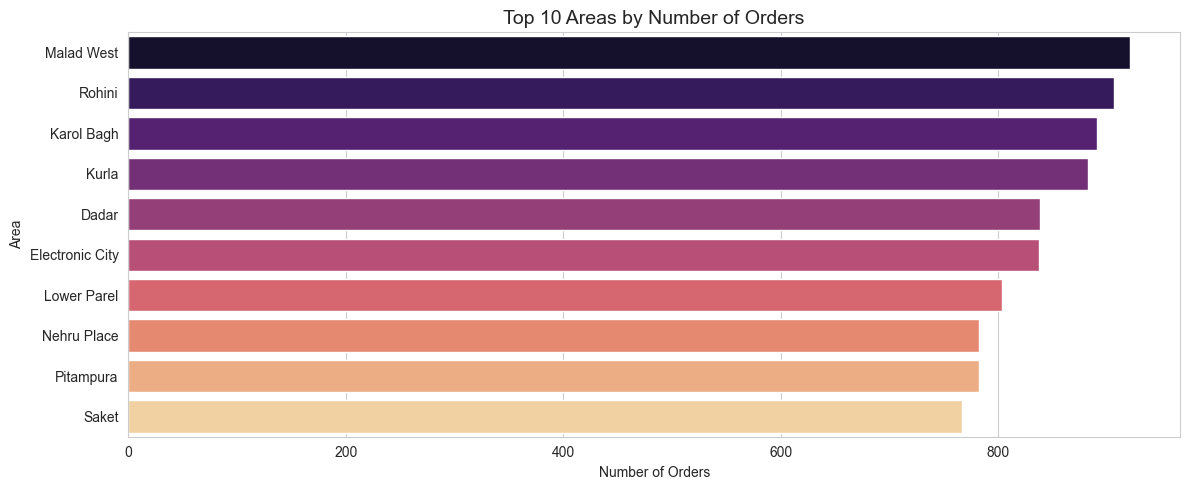

In [36]:
orders_with_area = orders.merge(
    restaurants[['restaurant_id', 'area', 'city']], on='restaurant_id'
)

top_areas = orders_with_area.groupby('area').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_areas.values, y=top_areas.index, palette='magma')
plt.title('Top 10 Areas by Number of Orders', fontsize=14)
plt.xlabel('Number of Orders')
plt.ylabel('Area')
plt.tight_layout()
plt.show()

### Plot 12 — Payment Mode Preference

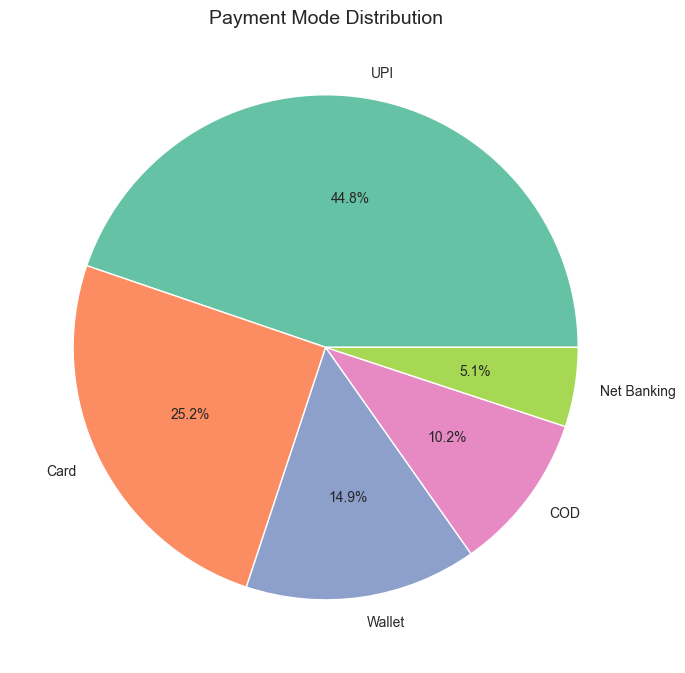

In [37]:
payment_counts = orders['payment_mode'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2'))
plt.title('Payment Mode Distribution', fontsize=14)
plt.tight_layout()
plt.show()

### Summary

In [38]:
# Delhi and Mumbai have the highest number of restaurants
# North Indian and Chinese cuisines are most common
# Dinner is the busiest time slot
# UPI is the most preferred payment mode
# Mumbai and Delhi have higher average prices than other cities
# Most customers give ratings between 3.5 and 5.0

### Feature Engineering

In [39]:
# In this notebook, we will:

# Merge all tables into a master dataframe
# Create new useful features from existing data
# Encode categorical variables
# Prepare the final dataset for ML model training

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

pd.set_option('display.max_columns', None)

### Filter Only Delivered Orders

In [41]:
# We only want delivered orders for analysis
delivered_orders = orders[orders['order_status'] == 'Delivered'].copy()
print(f'Total orders     : {len(orders)}')
print(f'Delivered orders : {len(delivered_orders)}')

Total orders     : 50000
Delivered orders : 41128


### Calculate Average Rating per Restaurant

In [42]:
# Average rating per restaurant from reviews
avg_rating = reviews.groupby('restaurant_id')['overall_rating'].mean().reset_index()
avg_rating.columns = ['restaurant_id', 'avg_rating']

print('Avg rating sample:')
print(avg_rating.head())

Avg rating sample:
  restaurant_id  avg_rating
0         R1001    3.700000
1         R1002    4.037500
2         R1003    3.821053
3         R1004    3.815385
4         R1005    3.915385


### Calculate Total Orders per Restaurant

In [43]:
# Count delivered orders per restaurant
order_counts = delivered_orders.groupby('restaurant_id').size().reset_index()
order_counts.columns = ['restaurant_id', 'total_orders']

print('Order count sample:')
print(order_counts.head())

Order count sample:
  restaurant_id  total_orders
0         R1001             8
1         R1002            13
2         R1003            23
3         R1004            14
4         R1005            17


### Merge Everything into a Master Table

In [44]:
# Start with restaurants as the base
master = restaurants.copy()

# Add average rating
master = master.merge(avg_rating, on='restaurant_id', how='left')

# Add total orders
master = master.merge(order_counts, on='restaurant_id', how='left')

# Fill NaN (restaurants with no orders or no reviews yet)
master['avg_rating']   = master['avg_rating'].fillna(0)
master['total_orders'] = master['total_orders'].fillna(0)

print('Master table shape:', master.shape)
master.head()

Master table shape: (3000, 16)


,restaurant_id,restaurant_name,owner_name,city,area,latitude,longitude,cuisine_type,restaurant_type,avg_price_for_two,has_online_ordering,has_table_booking,opening_year,is_active,avg_rating,total_orders
0,R1001,Royal Kitchen,Neha Desai,Hyderabad,Banjara Hills,17.484118,78.485340,Mughlai,Cloud Kitchen,212,False,False,2011,True,3.700000,8.0
1,R1002,Om Lounge,Nikhil Khanna,Delhi,Pitampura,28.675331,77.175856,Mughlai,Fine Dining,1650,True,True,2023,True,4.037500,13.0
2,R1003,Dum Corner,Isha Gupta,Mumbai,Versova,19.025643,72.848791,North Indian,QSR,260,True,False,2010,True,3.821053,23.0
3,R1004,Golden Hub,Ananya Deshpande,Bangalore,Hebbal,12.898072,77.517389,Desserts & Beverages,Cafe,1200,True,False,2022,True,3.815385,14.0
4,R1005,Dhaba Palace,Preeti Malhotra,Delhi,South Extension,28.552377,77.130093,Chinese,Cafe,550,False,False,2020,True,3.915385,17.0


### Feature: Competition Density

In [45]:
# Competition density = how many restaurants of same cuisine in same area
competition = master.groupby(['area', 'cuisine_type']).size().reset_index()
competition.columns = ['area', 'cuisine_type', 'competition_density']

master = master.merge(competition, on=['area', 'cuisine_type'], how='left')

print('Competition density added!')
print(master[['restaurant_name', 'area', 'cuisine_type', 'competition_density']].head())

Competition density added!
  restaurant_name             area          cuisine_type  competition_density
0   Royal Kitchen    Banjara Hills               Mughlai                    1
1       Om Lounge        Pitampura               Mughlai                    4
2      Dum Corner          Versova          North Indian                    3
3      Golden Hub           Hebbal  Desserts & Beverages                    3
4    Dhaba Palace  South Extension               Chinese                    9


### Feature: Cuisine Popularity Score per Area

In [46]:
# Popularity score = avg(total_orders * avg_rating) for cuisine in that area
popularity = master.groupby(['area', 'cuisine_type']).apply(
    lambda x: (x['total_orders'] * x['avg_rating']).mean()
).reset_index()
popularity.columns = ['area', 'cuisine_type', 'cuisine_popularity_score']

master = master.merge(popularity, on=['area', 'cuisine_type'], how='left')

print('Cuisine popularity score added!')

Cuisine popularity score added!


C:\Users\Care\AppData\Local\Temp\ipykernel_2000\2339449539.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  popularity = master.groupby(['area', 'cuisine_type']).apply(


### Feature: Demand Supply Gap

In [47]:
# Normalize both columns to 0-1 scale before subtraction
scaler = MinMaxScaler()

master['popularity_norm']   = scaler.fit_transform(master[['cuisine_popularity_score']])
master['competition_norm']  = scaler.fit_transform(master[['competition_density']])

# demand_supply_gap = high demand - high competition
master['demand_supply_gap'] = master['popularity_norm'] - master['competition_norm']

print('Demand Supply Gap added!')
print(master[['area', 'cuisine_type', 'demand_supply_gap']].head(8))

Demand Supply Gap added!
              area          cuisine_type  demand_supply_gap
0    Banjara Hills               Mughlai           0.223383
1        Pitampura               Mughlai           0.244034
2          Versova          North Indian           0.301559
3           Hebbal  Desserts & Beverages           0.179926
4  South Extension               Chinese          -0.082920
5           Colaba          South Indian           0.200566
6        Pitampura             Fast Food          -0.046276
7          JM Road           Street Food           0.171918


### Feature: Average Order Value per Area

In [48]:
# Merge orders with restaurants to get area
orders_with_area = delivered_orders.merge(
    restaurants[['restaurant_id', 'area']], on='restaurant_id'
)

avg_order_value = orders_with_area.groupby('area')['total_amount'].mean().reset_index()
avg_order_value.columns = ['area', 'avg_order_value']

master = master.merge(avg_order_value, on='area', how='left')
master['avg_order_value'] = master['avg_order_value'].fillna(master['avg_order_value'].mean())

print('Avg Order Value per area added!')

Avg Order Value per area added!


### Create Target Labels

In [49]:
# For MODEL 1 (Find Best Location):
# Target = area with best demand_supply_gap for that cuisine
# We use 'area' as the target label

# For MODEL 2 (Find Best Cuisine for a Location):
# Target = cuisine_type that performs best in that area
# We use 'cuisine_type' as the target label

print('Target columns:')
print('  Model 1 target -> area')
print('  Model 2 target -> cuisine_type')
print()
print('Unique areas  :', master['area'].nunique())
print('Unique cuisines:', master['cuisine_type'].nunique())

Target columns:
  Model 1 target -> area
  Model 2 target -> cuisine_type

Unique areas  : 105
Unique cuisines: 15


### Encode Categorical Columns

In [50]:
# We will encode: city, area, cuisine_type, restaurant_type
le_city    = LabelEncoder()
le_area    = LabelEncoder()
le_cuisine = LabelEncoder()
le_type    = LabelEncoder()

master['city_encoded']    = le_city.fit_transform(master['city'])
master['area_encoded']    = le_area.fit_transform(master['area'])
master['cuisine_encoded'] = le_cuisine.fit_transform(master['cuisine_type'])
master['type_encoded']    = le_type.fit_transform(master['restaurant_type'])

# Boolean columns to int
master['has_online_ordering'] = master['has_online_ordering'].astype(int)
master['has_table_booking']   = master['has_table_booking'].astype(int)
master['is_active']           = master['is_active'].astype(int)

print('Encoding done!')
print(master[['cuisine_type', 'cuisine_encoded', 'area', 'area_encoded']].head())

Encoding done!
           cuisine_type  cuisine_encoded             area  area_encoded
0               Mughlai                8    Banjara Hills            10
1               Mughlai                8        Pitampura            78
2          North Indian                9          Versova            99
3  Desserts & Beverages                4           Hebbal            37
4               Chinese                2  South Extension            92


### Final Feature List

In [51]:
# Features we will use for MODEL 1 (predict best area)
features_model1 = [
    'cuisine_encoded',
    'type_encoded',
    'avg_price_for_two',
    'has_online_ordering',
    'has_table_booking',
    'competition_density',
    'cuisine_popularity_score',
    'demand_supply_gap',
    'avg_order_value'
]
target_model1 = 'area_encoded'

# Features we will use for MODEL 2 (predict best cuisine)
features_model2 = [
    'city_encoded',
    'area_encoded',
    'avg_price_for_two',
    'competition_density',
    'cuisine_popularity_score',
    'demand_supply_gap',
    'avg_order_value'
]
target_model2 = 'cuisine_encoded'

print('Features for Model 1 (Best Location):')
print(features_model1)
print()
print('Features for Model 2 (Best Cuisine):')
print(features_model2)

Features for Model 1 (Best Location):
['cuisine_encoded', 'type_encoded', 'avg_price_for_two', 'has_online_ordering', 'has_table_booking', 'competition_density', 'cuisine_popularity_score', 'demand_supply_gap', 'avg_order_value']

Features for Model 2 (Best Cuisine):
['city_encoded', 'area_encoded', 'avg_price_for_two', 'competition_density', 'cuisine_popularity_score', 'demand_supply_gap', 'avg_order_value']


### Save Master Table

In [53]:
master.to_csv(r'C:\Users\Care\notebooks\master_features.csv', index=False)
print('Shape:', master.shape)
master.head()

Shape: (3000, 26)


,restaurant_id,restaurant_name,owner_name,city,area,latitude,longitude,cuisine_type,restaurant_type,avg_price_for_two,has_online_ordering,has_table_booking,opening_year,is_active,avg_rating,total_orders,competition_density,cuisine_popularity_score,popularity_norm,competition_norm,demand_supply_gap,avg_order_value,city_encoded,area_encoded,cuisine_encoded,type_encoded
0,R1001,Royal Kitchen,Neha Desai,Hyderabad,Banjara Hills,17.484118,78.485340,Mughlai,Cloud Kitchen,212,0,0,2011,1,3.700000,8.0,1,29.600000,0.223383,0.000000,0.223383,506.713959,3,10,8,2
1,R1002,Om Lounge,Nikhil Khanna,Delhi,Pitampura,28.675331,77.175856,Mughlai,Fine Dining,1650,1,1,2023,1,4.037500,13.0,4,62.915057,0.474803,0.230769,0.244034,542.740900,2,78,8,4
2,R1003,Dum Corner,Isha Gupta,Mumbai,Versova,19.025643,72.848791,North Indian,QSR,260,1,0,2010,1,3.821053,23.0,3,60.344737,0.455406,0.153846,0.301559,550.915374,5,99,9,5
3,R1004,Golden Hub,Ananya Deshpande,Bangalore,Hebbal,12.898072,77.517389,Desserts & Beverages,Cafe,1200,1,0,2022,1,3.815385,14.0,3,44.227350,0.333772,0.153846,0.179926,652.931508,0,37,4,0
4,R1005,Dhaba Palace,Preeti Malhotra,Delhi,South Extension,28.552377,77.130093,Chinese,Cafe,550,0,0,2020,1,3.915385,17.0,9,70.555617,0.532464,0.615385,-0.082920,567.386678,2,92,2,0


### Model Building & Evaluation

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

sns.set_style('whitegrid')
os.makedirs(r'C:\Users\Care\notebooks\models', exist_ok=True)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### MODEL 1 — Find Best Location

In [55]:
# Input: Cuisine type, restaurant type, price range
# Output: Best area to open the restaurant

In [56]:
# Define features and target for Model 1
features_m1 = [
    'cuisine_encoded',
    'type_encoded',
    'avg_price_for_two',
    'has_online_ordering',
    'has_table_booking',
    'competition_density',
    'cuisine_popularity_score',
    'demand_supply_gap',
    'avg_order_value'
]
target_m1 = 'area_encoded'

X1 = master[features_m1]
y1 = master[target_m1]

# Train-test split (80% train, 20% test)
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

print('Model 1 - Training data size :', X1_train.shape)
print('Model 1 - Testing data size  :', X1_test.shape)

Model 1 - Training data size : (2400, 9)
Model 1 - Testing data size  : (600, 9)


In [57]:
# Train Random Forest Classifier for Model 1
model1 = RandomForestClassifier(n_estimators=100, random_state=42)
model1.fit(X1_train, y1_train)

# Predict on test data
y1_pred = model1.predict(X1_test)

# Accuracy
acc1 = accuracy_score(y1_test, y1_pred)
print(f'Model 1 Accuracy: {acc1 * 100:.2f}%')

Model 1 Accuracy: 90.67%


C:\Users\Care\AppData\Local\Temp\ipykernel_2000\2418994683.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance1.values, y=importance1.index, palette='viridis')


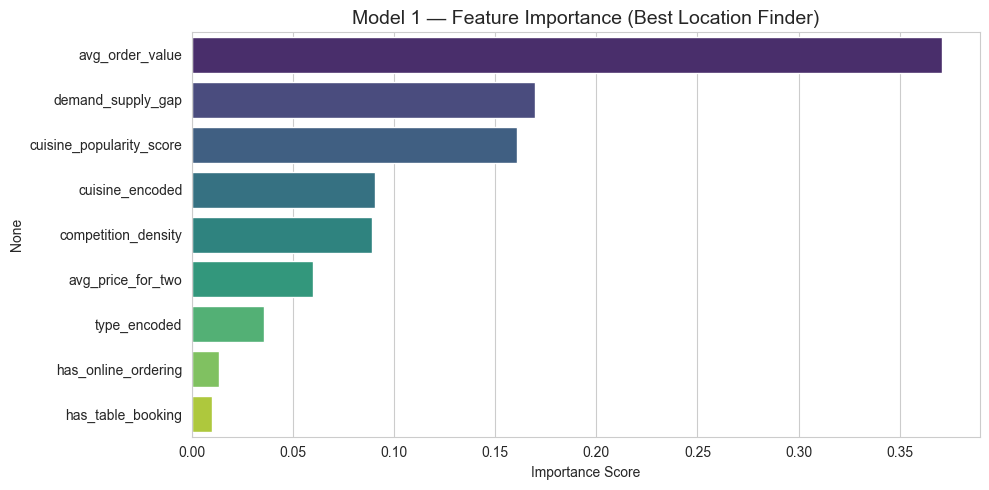

In [58]:
# Feature importance for Model 1
importance1 = pd.Series(model1.feature_importances_, index=features_m1).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importance1.values, y=importance1.index, palette='viridis')
plt.title('Model 1 — Feature Importance (Best Location Finder)', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

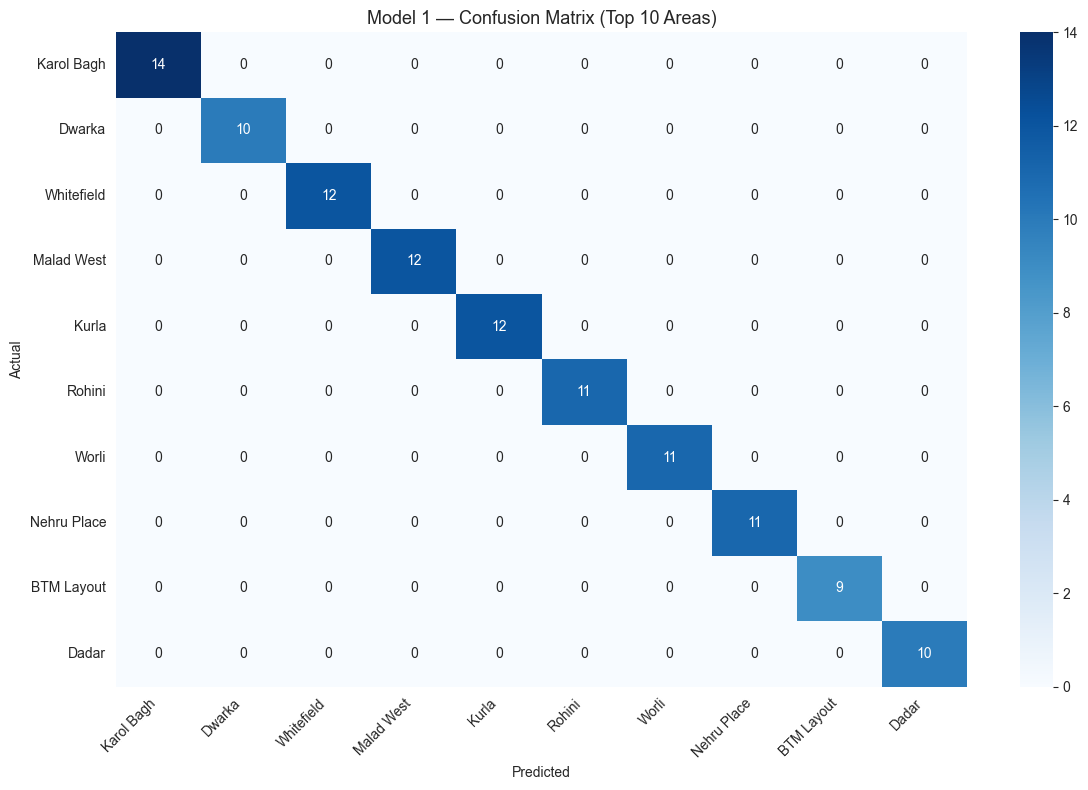

In [59]:
# Confusion Matrix for Model 1 (top 10 classes only for readability)
# Show top 10 most predicted areas
from collections import Counter
top10_classes = [x[0] for x in Counter(y1_test.tolist()).most_common(10)]

mask = y1_test.isin(top10_classes)
cm1 = confusion_matrix(y1_test[mask], y1_pred[mask], labels=top10_classes)
top10_labels = le_area.inverse_transform(top10_classes)

plt.figure(figsize=(12, 8))
sns.heatmap(cm1, xticklabels=top10_labels, yticklabels=top10_labels,
            annot=True, fmt='d', cmap='Blues')
plt.title('Model 1 — Confusion Matrix (Top 10 Areas)', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### MODEL 2 — Find Best Restaurant Type

In [60]:
# Input: City, area, budget range
# Output: Best cuisine type to serve

In [61]:
# Define features and target for Model 2
features_m2 = [
    'city_encoded',
    'area_encoded',
    'avg_price_for_two',
    'competition_density',
    'cuisine_popularity_score',
    'demand_supply_gap',
    'avg_order_value'
]
target_m2 = 'cuisine_encoded'

X2 = master[features_m2]
y2 = master[target_m2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

print('Model 2 - Training data size :', X2_train.shape)
print('Model 2 - Testing data size  :', X2_test.shape)

Model 2 - Training data size : (2400, 7)
Model 2 - Testing data size  : (600, 7)


In [62]:
# Train Random Forest Classifier for Model 2
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

acc2 = accuracy_score(y2_test, y2_pred)
print(f'Model 2 Accuracy: {acc2 * 100:.2f}%')

Model 2 Accuracy: 81.17%


C:\Users\Care\AppData\Local\Temp\ipykernel_2000\1545034976.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance2.values, y=importance2.index, palette='magma')


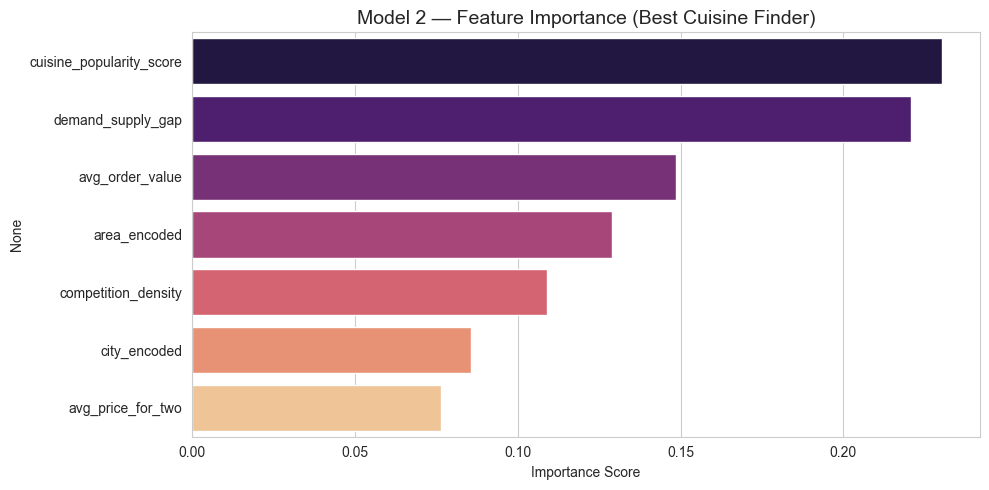

In [63]:
# Feature importance for Model 2
importance2 = pd.Series(model2.feature_importances_, index=features_m2).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importance2.values, y=importance2.index, palette='magma')
plt.title('Model 2 — Feature Importance (Best Cuisine Finder)', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [64]:
# Classification report for Model 2
cuisine_names = le_cuisine.inverse_transform(sorted(y2.unique()))
print('Classification Report — Model 2:')
print(classification_report(y2_test, y2_pred, target_names=cuisine_names))

Classification Report — Model 2:
                      precision    recall  f1-score   support

             Bengali       0.59      0.57      0.58        23
             Biryani       0.91      0.74      0.82        42
             Chinese       0.97      0.92      0.94        73
         Continental       0.87      0.97      0.92        35
Desserts & Beverages       0.35      0.40      0.37        20
           Fast Food       0.73      0.81      0.77        37
             Italian       0.29      0.38      0.33        13
       Maharashtrian       0.73      0.63      0.68        30
             Mughlai       0.73      0.76      0.75        25
        North Indian       0.94      0.99      0.96        96
               Pizza       0.62      0.50      0.55        16
             Seafood       0.87      0.79      0.83        43
        South Indian       0.90      0.92      0.91        65
         Street Food       0.86      0.86      0.86        49
             Tandoor       0.65     

### Side by Side Model Accuracy Comparison

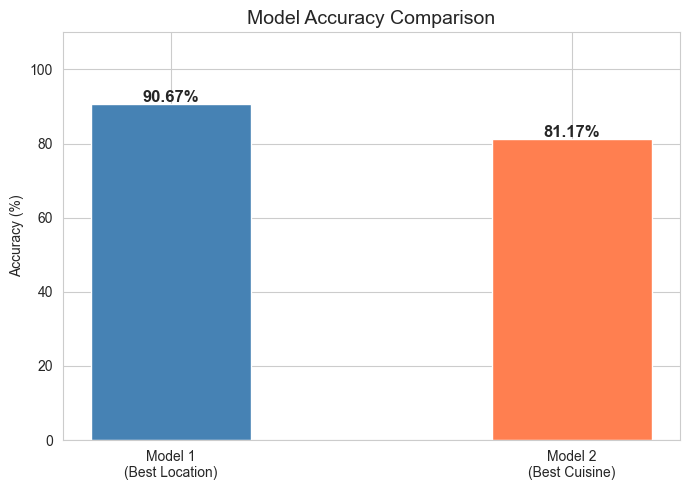

In [65]:
models = ['Model 1\n(Best Location)', 'Model 2\n(Best Cuisine)']
accuracies = [acc1 * 100, acc2 * 100]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'coral'], width=0.4)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.ylim(0, 110)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()

### Save All Models and Encoders

In [78]:
# Save models
joblib.dump(model1, r'C:\Users\Care\notebooks\models\location_model.pkl')
joblib.dump(model2, r'C:\Users\Care\notebooks\models\cuisine_model.pkl')

# Save label encoders
joblib.dump(le_area,    r'C:\Users\Care\notebooks\models\label_encoder_area.pkl')
joblib.dump(le_cuisine, r'C:\Users\Care\notebooks\models\label_encoder_cuisine.pkl')
joblib.dump(le_city,    r'C:\Users\Care\notebooks\models\label_encoder_city.pkl')
joblib.dump(le_type,    r'C:\Users\Care\notebooks\models\label_encoder_type.pkl')

# Save the feature data needed by the app for lookup
feature_data = master[[
    'area', 'city', 'cuisine_type', 'restaurant_type',
    'avg_price_for_two', 'competition_density',
    'cuisine_popularity_score', 'demand_supply_gap',
    'avg_order_value', 'avg_rating', 'total_orders',
    'area_encoded', 'city_encoded', 'cuisine_encoded', 'type_encoded',
    'has_online_ordering', 'has_table_booking'
]].copy()

joblib.dump(feature_data, r'C:\Users\Care\notebooks\models\feature_data.pkl')

print('All models and encoders saved to \models folder!')
print()
print('Files saved:')
import os
for f in os.listdir(r'C:\Users\Care\notebooks\models'):
    print(' -', f)

All models and encoders saved to \models folder!

Files saved:
 - cuisine_model.pkl
 - feature_data.pkl
 - label_encoder_area.pkl
 - label_encoder_city.pkl
 - label_encoder_cuisine.pkl
 - label_encoder_type.pkl
 - location_model.pkl
